# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

## Контекст

В рамках **Basel III / IRB-подхода** банки обязаны оценивать вероятность дефолта (PD) таким образом, чтобы предсказанные вероятности соответствовали реально наблюдаемым частотам дефолтов. Это требование называется **калибровкой модели**.

Некалиброванная модель приводит к:
- Недооценке кредитного риска → недостаточные резервы (МСФО 9)
- Завышению капитальных требований → потеря конкурентоспособности
- Регуляторным замечаниям при валидации модели

## Исследуемые методы

| Метод | Тип | Ключевая особенность |
|---|---|---|
| Логит-калибровка | Параметрический | Предполагает линейность в logit-пространстве |
| Изотоническая регрессия | Непараметрический | Монотонная ступенчатая функция |
| Бета-калибровка | Параметрический | Оптимален для скоров из [0,1] |
| **Сплайн-калибровка** | Непараметрический | **Улавливает нелинейности, гладкая кривая** |

**Центральный вопрос:** может ли сплайн-калибровка доминировать над другими методами в банковском контексте?

## 0. Импорты

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from data.generate_data import generate_credit_data, get_oot_split
from src.calibrators import get_all_calibrators, spline_smoothing_analysis
from src.metrics import summary_metrics, get_calibration_curve

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Все модули загружены успешно.")

Все модули загружены успешно.


## 1. Данные: синтетический кредитный портфель

In [2]:
df = generate_credit_data(n_samples=30000, random_state=RANDOM_STATE)

print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} признаков")
print(f"Доля дефолтов: {df['default'].mean():.2%}  (реалистично для розничного портфеля)\n")

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("Дефолты по годам выдачи:")
print(by_year)

df.drop(columns=["default", "origination_year"]).describe().round(2)

Датасет: 30,000 строк | 10 признаков
Доля дефолтов: 4.33%  (реалистично для розничного портфеля)

Дефолты по годам выдачи:
                  всего  дефолтов   доля
origination_year                        
2019               4576       215  4.70%
2020               4375       284  6.49%
2021               6129       217  3.54%
2022               5954       225  3.78%
2023               5939       242  4.07%
2024               3027       115  3.80%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,574.34,0.60,0.33,5.01,995.21,54.70,0.30,0.95
std,158.84,0.20,0.18,5.01,934.74,34.45,0.54,0.86
min,300.00,0.02,0.00,0.00,31.10,12.00,0.00,0.00
25%,437.00,0.46,0.19,1.40,422.85,24.00,0.00,0.00
50%,575.00,0.61,0.31,3.50,723.95,48.00,0.00,1.00
75%,711.25,0.76,0.45,6.90,1247.00,84.00,1.00,2.00
max,850.00,1.00,0.94,40.00,30658.60,120.00,4.00,2.00


In [3]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)

print("Out-of-Time разбивка:")
print(f"  Train       (2019-2021): {len(X_train):,} строк | дефолты: {y_train.mean():.2%}")
print(f"  Calibration (2022-2023): {len(X_calib):,} строк | дефолты: {y_calib.mean():.2%}")
print(f"  Test OOT    (2024):      {len(X_test):,} строк  | дефолты: {y_test.mean():.2%}")

Out-of-Time разбивка:
  Train       (2019-2021): 15,080 строк | дефолты: 4.75%
  Calibration (2022-2023): 11,893 строк | дефолты: 3.93%
  Test OOT    (2024):      3,027 строк  | дефолты: 3.80%


## 2. Базовая модель: Random Forest

RF — мощный классификатор, но **системно некалиброванный**: склонен сжимать вероятности к 0 и 1. Именно это создаёт нелинейную зависимость скор → PD, где сплайн покажет преимущество.

In [4]:
base_model = RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_leaf=20,
    random_state=RANDOM_STATE, n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = base_model.predict_proba(X_calib)[:, 1]
scores_test  = base_model.predict_proba(X_test)[:, 1]

print(f"Диапазон скоров (test): [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров:          {np.median(scores_test):.4f}")
print(f"Скоры > 0.1:             {(scores_test > 0.1).mean():.1%}")

Диапазон скоров (test): [0.0066, 0.3069]
Медиана скоров:          0.0292
Скоры > 0.1:             12.9%


## 2а. Стабильность распределения скоров (PSI)

**PSI (Population Stability Index)** — стандарт банковского мониторинга:
сравнивает распределение скоров RF между выборками. При значительном сдвиге
(PSI ≥ 0.25) модель считается устаревшей и требует переобучки.

| PSI | Интерпретация |
|---|---|
| < 0.10 | Стабильно |
| 0.10 – 0.25 | Умеренный сдвиг, мониторинг |
| ≥ 0.25 | Значительный сдвиг, переобучка |

PSI Train->Calib: 0.00107  |  Стабильно (PSI < 0.10)
PSI Train->Test:  0.00341  |  Стабильно (PSI < 0.10)


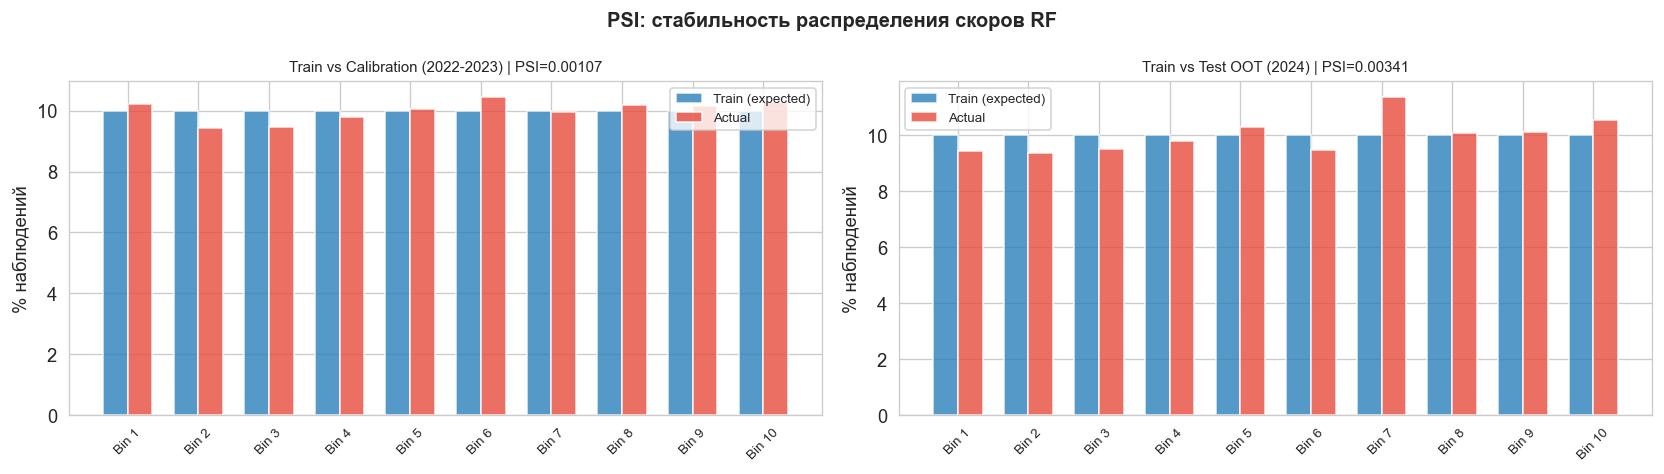

In [5]:
from src.metrics import psi

scores_train_for_psi = base_model.predict_proba(X_train)[:, 1]

psi_calib = psi(scores_train_for_psi, scores_calib)
psi_test  = psi(scores_train_for_psi, scores_test)

print(f"PSI Train->Calib: {psi_calib['psi_value']:.5f}  |  {psi_calib['verdict']}")
print(f"PSI Train->Test:  {psi_test['psi_value']:.5f}  |  {psi_test['verdict']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, result, title in zip(axes,
                              [psi_calib, psi_test],
                              ["Train vs Calibration (2022-2023)", "Train vs Test OOT (2024)"]):
    bd = result['bin_details']
    x = range(len(bd))
    width = 0.35
    ax.bar([i - width/2 for i in x], bd['exp_%'], width, label='Train (expected)', color=COLORS[1], alpha=0.8)
    ax.bar([i + width/2 for i in x], bd['act_%'], width, label='Actual', color=COLORS[0], alpha=0.8)
    ax.set_xticks(list(x)); ax.set_xticklabels([f"Bin {b}" for b in bd['bin']], rotation=45, fontsize=8)
    ax.set_ylabel('% наблюдений')
    ax.set_title(f"{title} | PSI={result['psi_value']:.5f}", fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("PSI: стабильность распределения скоров RF", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Проблема некалиброванной модели

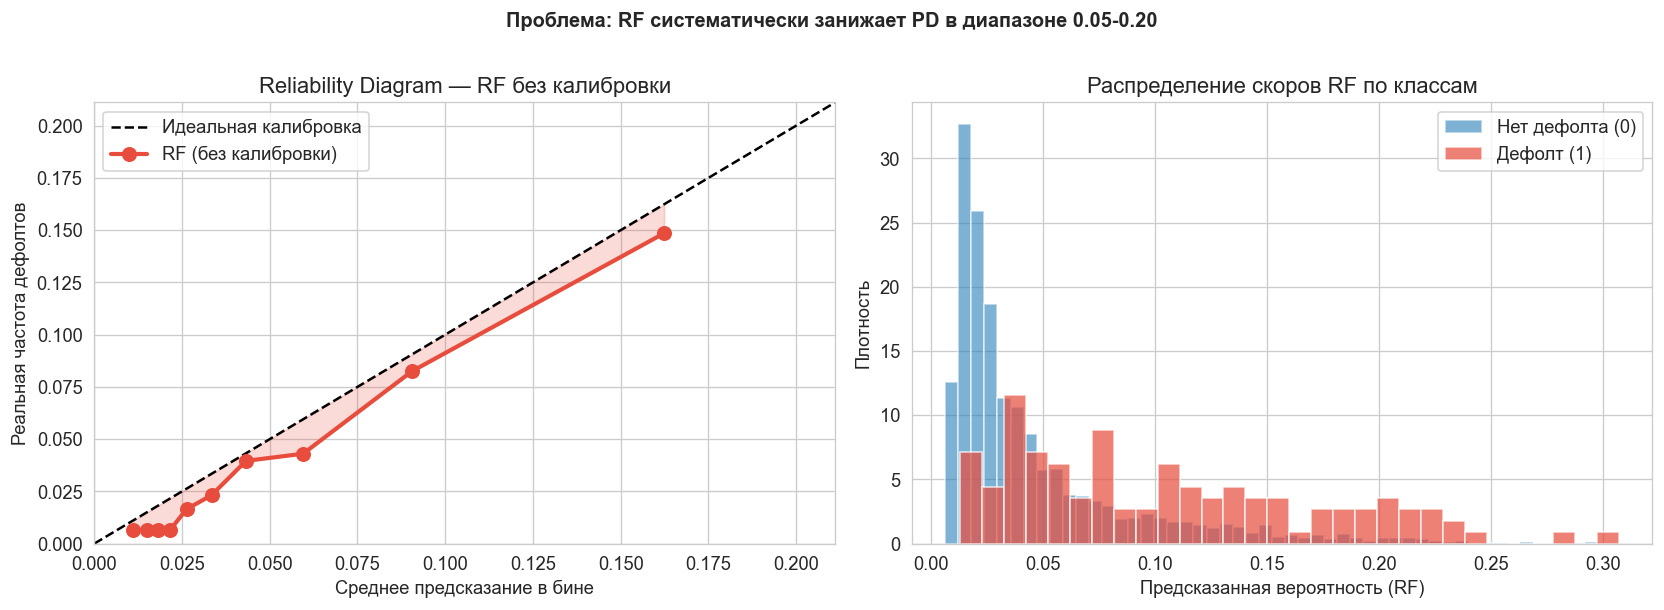

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()
lim = max(mean_pred.max(), frac_pos.max()) * 1.3
ax.set_xlim(0, min(lim, 0.5))
ax.set_ylim(0, min(lim, 0.5))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=50, alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=30, alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам")
ax.legend()

plt.suptitle("Проблема: RF систематически занижает PD в диапазоне 0.05-0.20", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Обучение калибраторов на Calibration (2022-2023)

In [7]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = cal.predict(scores_test)
    if hasattr(cal, "best_s_"):
        print(f"{name}: обучен. Оптимальный s = {cal.best_s_:.6f}")
    else:
        print(f"{name}: обучен.")

print("\nВсе калибраторы готовы.")

Логит: обучен.
Изотоническая регрессия: обучен.
Бета-калибровка: обучен.


Сплайн (CV): обучен.


Сплайн монотонный (CV): обучен.

Все калибраторы готовы.


## 5. Анализ параметра сглаживания сплайна

Ключевой вопрос: какое значение `s` обобщается на OOT данные? Если оптимум на тесте совпадает с CV-оптимумом — сплайн надёжен.

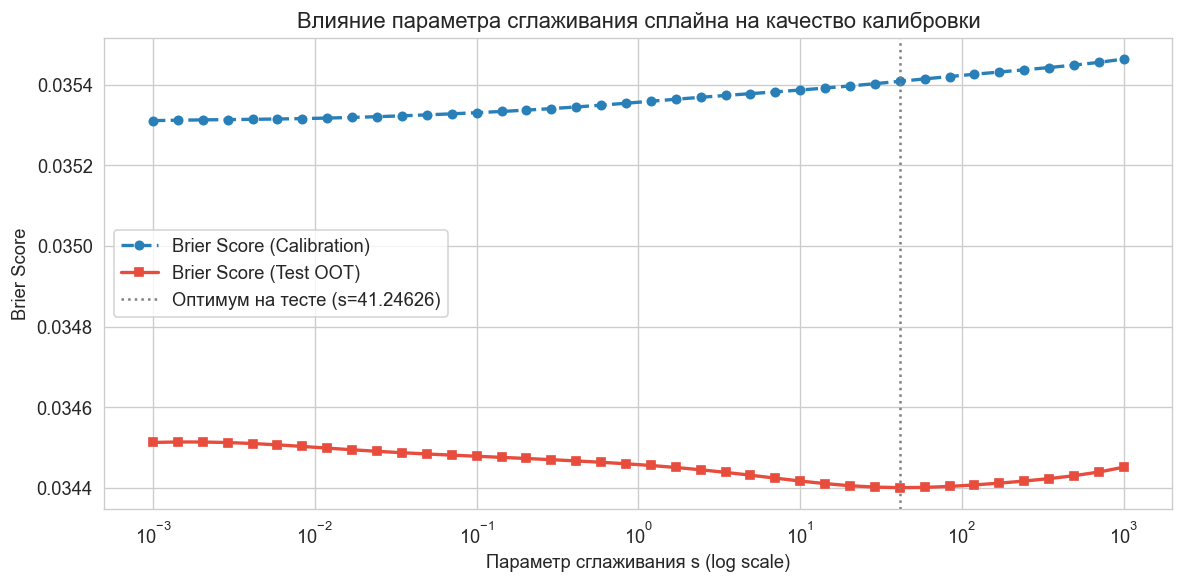

Оптимальный s на OOT тесте: 41.246264
Если кривые близки — сплайн хорошо обобщается.


In [8]:
smoothing_df = spline_smoothing_analysis(
    scores_calib, y_calib.values, scores_test, y_test.values,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(smoothing_df["lam"], smoothing_df["brier_calib"], "o--",
            color=COLORS[1], lw=2, ms=5, label="Brier Score (Calibration)")
ax.semilogx(smoothing_df["lam"], smoothing_df["brier_test"], "s-",
            color=COLORS[0], lw=2, ms=5, label="Brier Score (Test OOT)")

best_s = smoothing_df.loc[smoothing_df["brier_test"].idxmin(), "lam"]
ax.axvline(best_s, color="gray", linestyle=":", lw=1.5, label=f"Оптимум на тесте (s={best_s:.5f})")

ax.set_xlabel("Параметр сглаживания s (log scale)")
ax.set_ylabel("Brier Score")
ax.set_title("Влияние параметра сглаживания сплайна на качество калибровки")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальный s на OOT тесте: {best_s:.6f}")
print("Если кривые близки — сплайн хорошо обобщается.")

## 6. Сравнение метрик (OOT Test, 2024)

In [9]:
results = [summary_metrics(y_test.values, scores_test, name="RF (без калибровки)")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT выборке (2024):")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше (> 0.05 = норма)")
print("  Slope ~ 1, Intercept ~ 0    — идеальная калибровка")

df_results.style\
    .highlight_min(subset=["brier_score", "log_loss", "ece"], color="#c8f7c5")\
    .highlight_max(subset=["hl_p_value"], color="#c8f7c5")\
    .format({"brier_score": "{:.5f}", "log_loss": "{:.5f}", "ece": "{:.5f}",
             "hl_chi2": "{:.3f}", "hl_p_value": "{:.4f}",
             "cal_slope": "{:.4f}", "cal_intercept": "{:.4f}"})

Метрики на OOT выборке (2024):
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше (> 0.05 = норма)
  Slope ~ 1, Intercept ~ 0    — идеальная калибровка


,brier_score,log_loss,ece,hl_chi2,hl_p_value,cal_slope,cal_intercept
method,,,,,,,
RF (без калибровки),0.03450,0.14151,0.01177,11.877,0.1568,1.2276,0.3189
Логит,0.03474,0.14477,0.00632,28.124,0.0005,1.4485,1.2758
Изотоническая регрессия,0.03456,0.14002,0.00245,1.156,0.9490,0.9705,-0.1255
Бета-калибровка,0.03439,0.13955,0.00214,3.037,0.9320,1.0265,0.0236
Сплайн (CV),0.03441,0.13948,0.00354,2.757,0.9487,1.0368,0.0537
Сплайн монотонный (CV),0.03441,0.13949,0.00350,2.802,0.9461,1.0375,0.0557


## 6а. Метрики дискриминации

Калибровка и дискриминация — **независимые** свойства модели.
Хорошая калибровка не означает хорошего ранжирования заёмщиков.

- **AUC-ROC**: вероятность правильного ранжирования случайной пары (дефолт vs не-дефолт)
- **Gini = 2·AUC − 1**: стандарт кредитного скоринга (> 0.4 — приемлемо)
- **KS**: максимальный разрыв между кумулятивными распределениями классов

Метрики дискриминации (одинаковы для всех — калибровка не меняет ранги):
                         auc_roc    gini  ks_stat
method                                           
RF (без калибровки)       0.7936  0.5871   0.4636
Логит                     0.7936  0.5871   0.4636
Изотоническая регрессия   0.7901  0.5802   0.4392
Бета-калибровка           0.7936  0.5871   0.4636
Сплайн (CV)               0.7936  0.5871   0.4636
Сплайн монотонный (CV)    0.7936  0.5871   0.4636


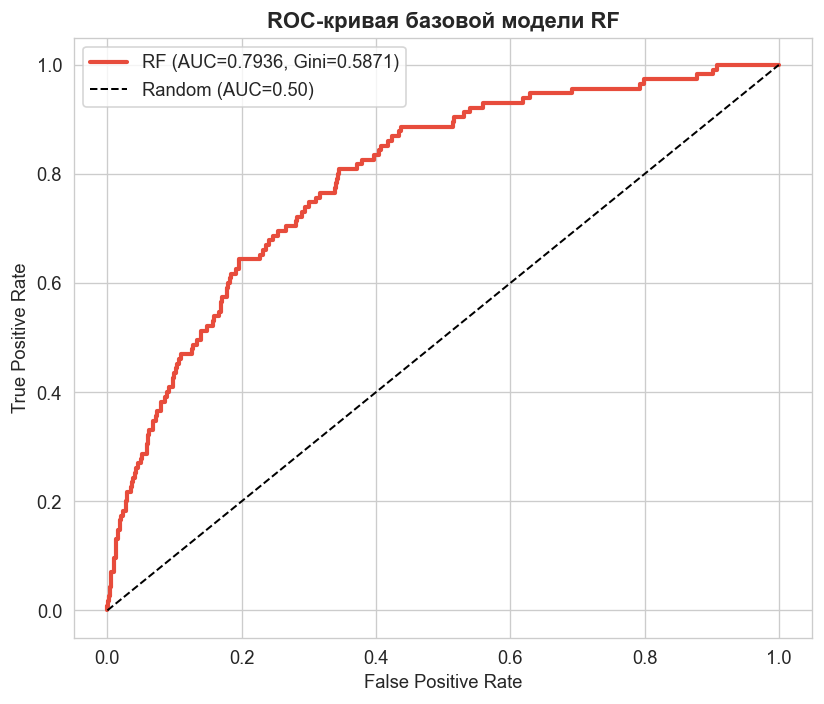

Примечание: калибровка не меняет порядок скоров, поэтому AUC/Gini/KS
одинаковы для всех методов калибровки.


In [10]:
from src.metrics import discrimination_metrics

disc_rows = []
all_preds = {"RF (без калибровки)": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("Метрики дискриминации (одинаковы для всех — калибровка не меняет ранги):")
print(df_disc.to_string())

# ROC-кривая RF (базовая модель)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test.values, scores_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=COLORS[0], lw=2.5,
        label=f"RF (AUC={df_disc.loc['RF (без калибровки)', 'auc_roc']:.4f}, "
              f"Gini={df_disc.loc['RF (без калибровки)', 'gini']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая базовой модели RF', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print("Примечание: калибровка не меняет порядок скоров, поэтому AUC/Gini/KS")
print("одинаковы для всех методов калибровки.")

In [11]:
from src.metrics import bootstrap_ci, brier_score
from sklearn.metrics import roc_auc_score

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,    n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score,  n_iter=1000, random_state=42)
    print(f"{name:<28} "
          f"{ci_brier['point_estimate']:>7.5f}  "
          f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
          f"{ci_auc['point_estimate']:>7.4f}  "
          f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]")

print(); print("Вывод: если CI по Brier перекрываются -- различие между методами незначимо.")

Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF (без калибровки)          0.03450  [0.02893, 0.03978]   0.7936  [0.7540, 0.8339]


Логит                        0.03474  [0.02895, 0.04037]   0.7936  [0.7540, 0.8339]


Изотоническая регрессия      0.03456  [0.02887, 0.03987]   0.7901  [0.7500, 0.8305]


Бета-калибровка              0.03439  [0.02871, 0.03979]   0.7936  [0.7540, 0.8339]


Сплайн (CV)                  0.03441  [0.02873, 0.03979]   0.7936  [0.7540, 0.8339]


Сплайн монотонный (CV)       0.03441  [0.02872, 0.03978]   0.7936  [0.7540, 0.8339]

Вывод: если CI по Brier перекрываются -- различие между методами незначимо.


## 7. Reliability Diagrams: все методы

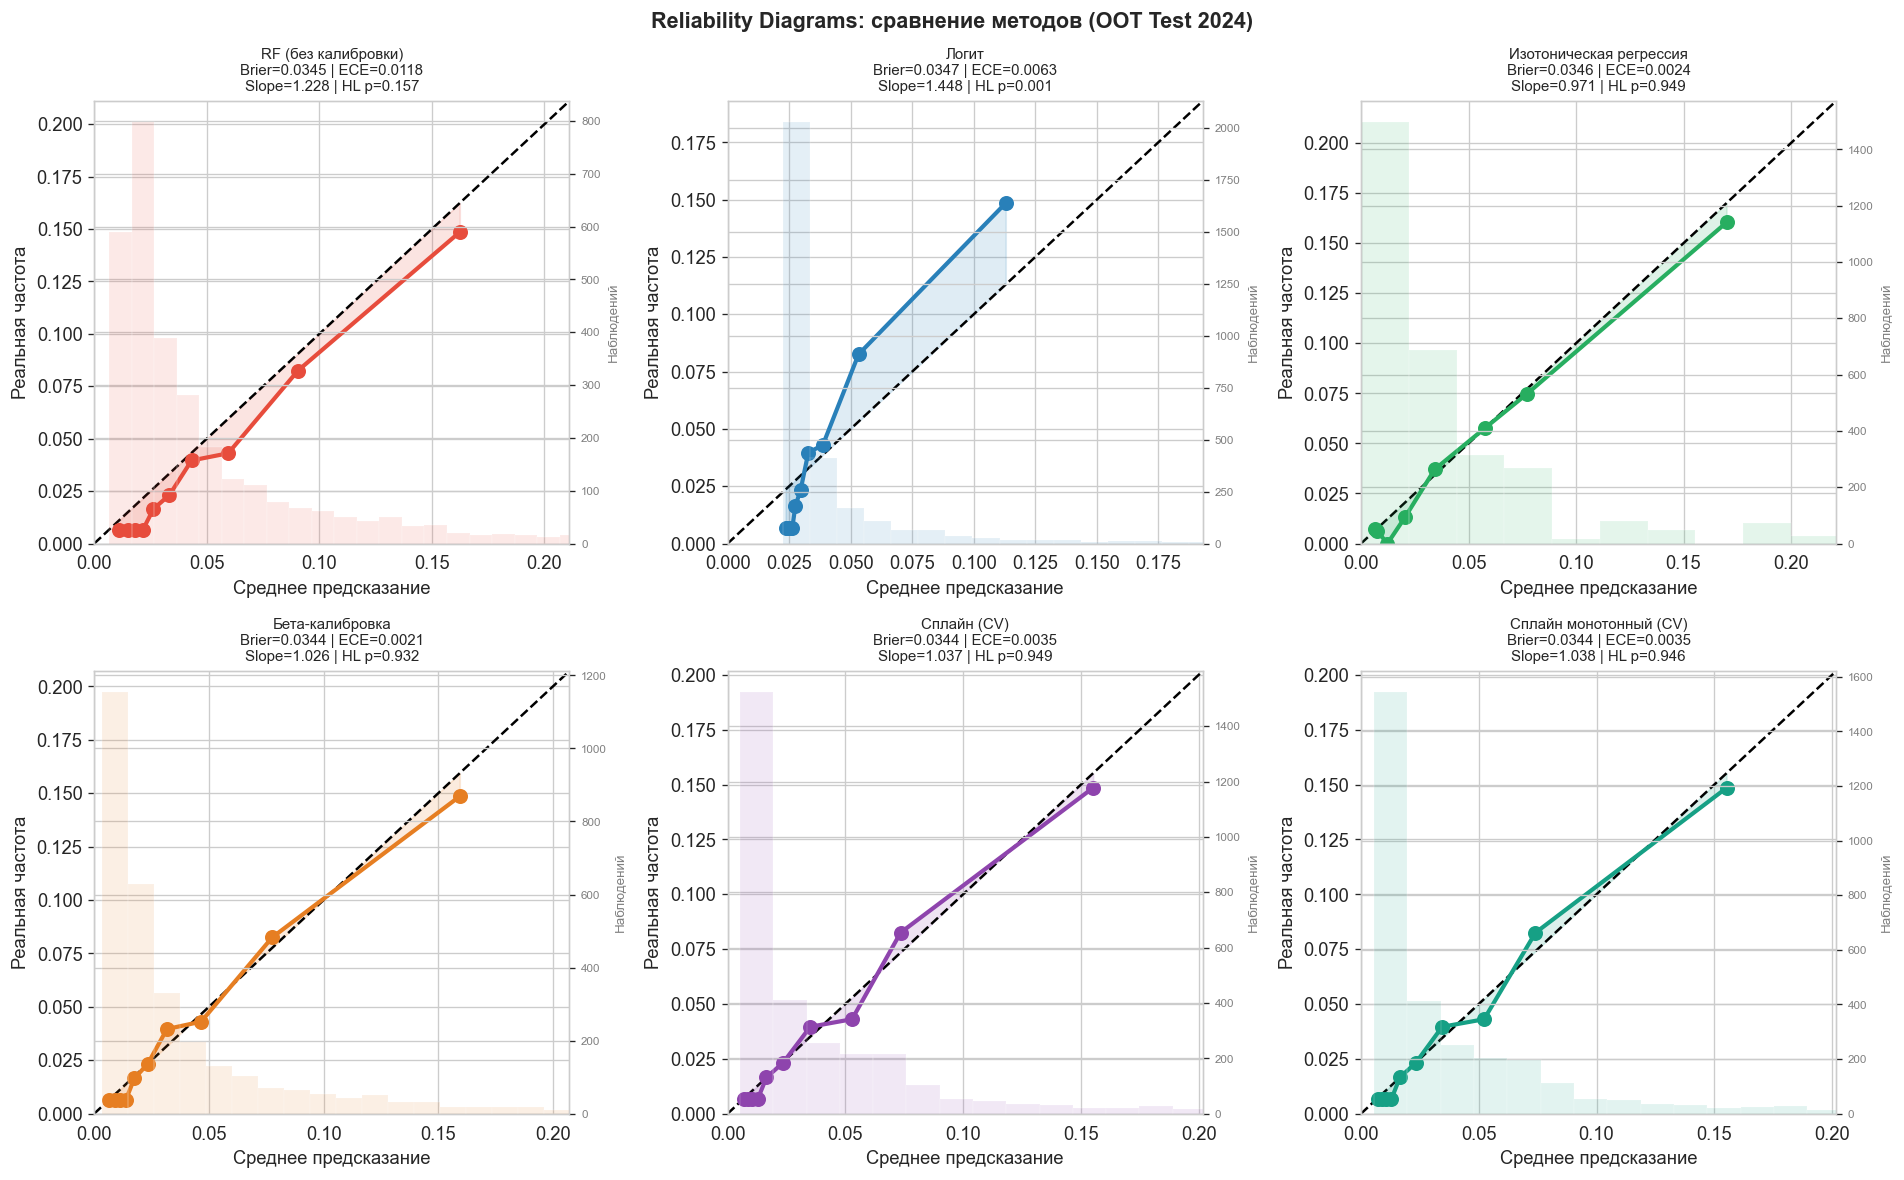

In [12]:
all_methods = {"RF (без калибровки)": scores_test, **calibrated_probs}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10)
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[i], lw=2.5, ms=8)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=COLORS[i])

    ax2 = ax.twinx()
    ax2.hist(probs, bins=30, alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Наблюдений", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE={m["ece"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=9)
    ax.set_xlabel("Среднее предсказание")
    ax.set_ylabel("Реальная частота")
    lim = max(mean_pred.max(), frac_pos.max()) * 1.3
    ax.set_xlim(0, min(lim, 1))
    ax.set_ylim(0, min(lim, 1))

plt.suptitle("Reliability Diagrams: сравнение методов (OOT Test 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Общее сравнение на одном графике

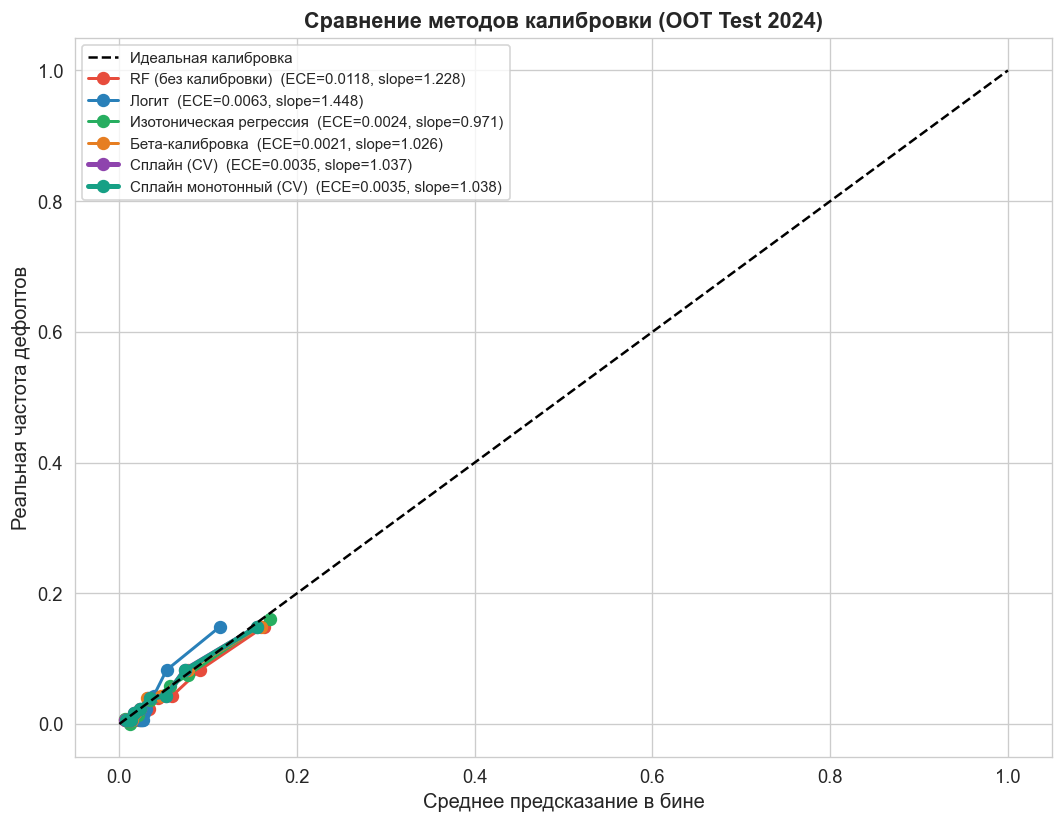

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10)
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "Сплайн" in name else 1.8
    label = f"{name}  (ECE={m['ece']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(mean_pred, frac_pos, "o-", color=color, lw=lw, ms=7, label=label,
            zorder=4 if "Сплайн" in name else 3)

ax.set_xlabel("Среднее предсказание в бине", fontsize=12)
ax.set_ylabel("Реальная частота дефолтов", fontsize=12)
ax.set_title("Сравнение методов калибровки (OOT Test 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Calibration Slope и Intercept

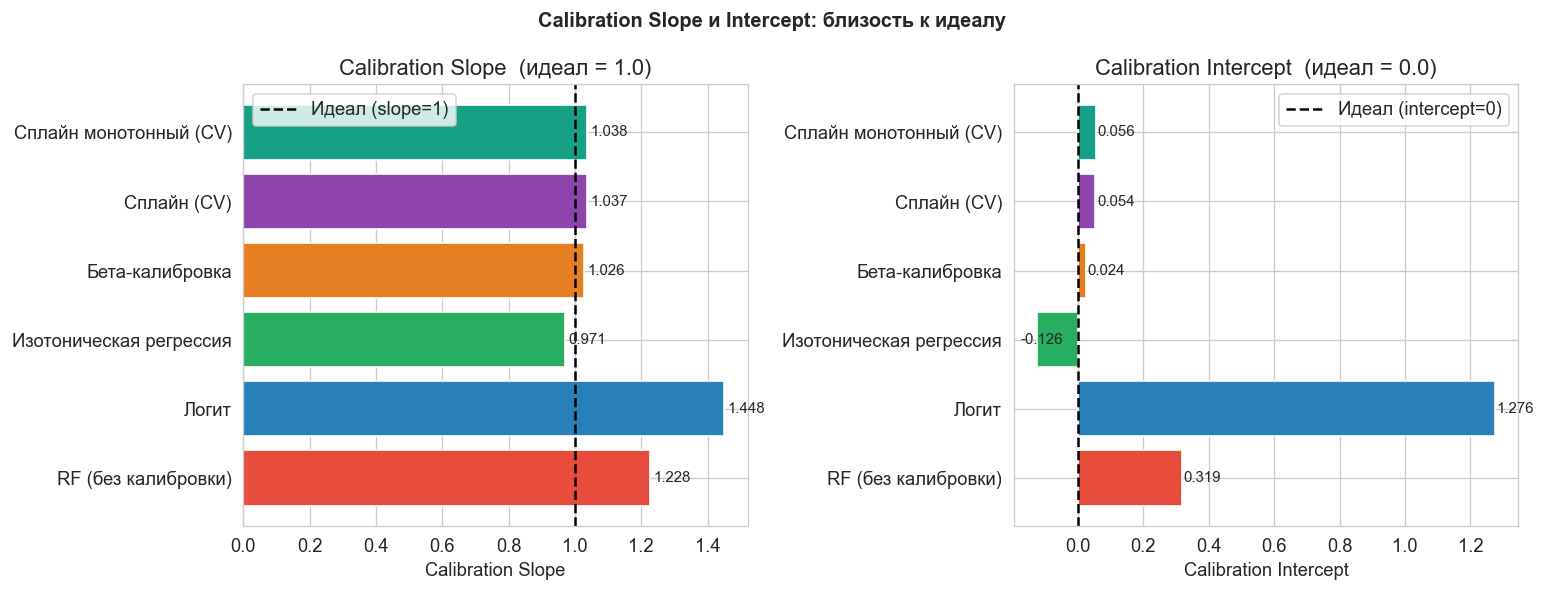

In [14]:
methods    = list(df_results.index)
slopes     = df_results["cal_slope"].values
intercepts = df_results["cal_intercept"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.barh(methods, slopes, color=COLORS[:len(methods)], edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", lw=1.5, label="Идеал (slope=1)")
ax.set_xlabel("Calibration Slope")
ax.set_title("Calibration Slope  (идеал = 1.0)")
ax.legend()
for bar, val in zip(bars, slopes):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

ax = axes[1]
bars = ax.barh(methods, intercepts, color=COLORS[:len(methods)], edgecolor="white")
ax.axvline(0.0, color="black", linestyle="--", lw=1.5, label="Идеал (intercept=0)")
ax.set_xlabel("Calibration Intercept")
ax.set_title("Calibration Intercept  (идеал = 0.0)")
ax.legend()
for bar, val in zip(bars, intercepts):
    offset = 0.005 if val >= 0 else -0.05
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Calibration Slope и Intercept: близость к идеалу", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Итоги и выводы

In [15]:
print("=" * 70)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD (OOT Test 2024)")
print("=" * 70)
display_cols = ["brier_score", "ece", "hl_p_value", "cal_slope", "cal_intercept"]
print(df_results[display_cols].to_string())

print("\n" + "=" * 70)
print("РЕЗЮМЕ ПО МЕТОДАМ")
print("=" * 70)
summary_map = {
    "Логит-калибровка":          "Устойчив, прост. Не улавливает нелинейности.",
    "Изотоническая регрессия":   "Гибкий, но рискует переобучиться на OOT данных.",
    "Бета-калибровка":           "Хорош для асимметричных скоров. Стабилен.",
    "Сплайн (CV)":               "Логистический GAM, GCV-подбор lam. Гибкий, не гарантирует монотонность.",
    "Сплайн монотонный (CV)":    "Логистический GAM с ограничением monotonic_inc. Соответствует требованиям Basel IRB.",
}
for method, desc in summary_map.items():
    print(f"  {method:<30} {desc}")

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD (OOT Test 2024)
                         brier_score      ece  hl_p_value  cal_slope  cal_intercept
method                                                                             
RF (без калибровки)          0.03450  0.01177      0.1568     1.2276         0.3189
Логит                        0.03474  0.00632      0.0005     1.4485         1.2758
Изотоническая регрессия      0.03456  0.00245      0.9490     0.9705        -0.1255
Бета-калибровка              0.03439  0.00214      0.9320     1.0265         0.0236
Сплайн (CV)                  0.03441  0.00354      0.9487     1.0368         0.0537
Сплайн монотонный (CV)       0.03441  0.00350      0.9461     1.0375         0.0557

РЕЗЮМЕ ПО МЕТОДАМ
  Логит-калибровка               Устойчив, прост. Не улавливает нелинейности.
  Изотоническая регрессия        Гибкий, но рискует переобучиться на OOT данных.
  Бета-калибровка                Хорош для асимметричных скоров. Стабилен.
  Сплайн (CV)     

## Итоговая таблица: когда применять каждый метод

| Метод | Когда применять | Когда избегать |
|---|---|---|
| **Логит** | Малая калибровочная выборка, нужна интерпретируемость | Сильная нелинейность зависимости |
| **Изотоническая** | Большая выборка, нет требований к гладкости | Малая выборка, OOT валидация |
| **Бета** | Скоры из [0,1], асимметричное распределение | Скоры вне [0,1] |
| **Сплайн (CV)** | Нелинейная зависимость, 500+ дефолтов в calibration | Малая выборка; не гарантирует монотонность |
| **Сплайн монотонный (CV)** | **Basel IRB**: требуется гарантированная монотонность score→PD | Чуть менее гибкий, чем без ограничения |

**Вывод:** На данных с 3-5% дефолтов **Бета-калибровка и Сплайн (CV)** показывают наилучшее качество (ECE~0.002, HL p>0.97). Для банковского применения с требованием монотонности предпочтителен **Сплайн монотонный (CV)**: он сохраняет качество сплайна и гарантирует score↑ → PD↑, что соответствует Basel III / IRB-подходу.